## 1. What is Boosting in Machine Learning? Explain how it improves weak learners.

Boosting is an ensemble learning technique in machine learning that combines multiple weak learners, usually decision trees with shallow depth, to form a strong learner.

It works sequentially:

1. A weak learner is trained on the dataset.
2. The errors made are identified, and higher weights are assigned to the misclassified samples.
3. A new weak learner is trained, focusing more on the difficult samples.
4. The predictions of all learners are combined using weighted voting (for classification) or weighted averaging (for regression).

This process reduces bias and variance, allowing the final model to achieve higher accuracy than individual weak learners.

Popular boosting algorithms include AdaBoost, Gradient Boosting, XGBoost, LightGBM, and CatBoost.

## 2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

### AdaBoost (Adaptive Boosting)

* Focuses on **reweighting training samples**.
* After each weak learner (e.g., decision stump) is trained:

  * Misclassified samples are given **higher weights**.
  * Correctly classified samples are given **lower weights**.
* The next learner focuses more on the **harder-to-classify samples**.
* Final prediction is a **weighted vote** of all learners.

**Training mechanism:** Emphasizes samples by changing their importance.

---

### Gradient Boosting

* Focuses on **optimizing the loss function**.
* Each new learner is trained to predict the **residual errors (gradients)** from the previous model.
* Instead of reweighting samples, it performs a **gradient descent step** on the loss function.
* Final prediction is the sum of the contributions from all learners.

**Training mechanism:** Reduces errors by fitting learners to the negative gradients of the loss.

---

## 3. How does regularization help in XGBoost?

Regularization in **XGBoost** helps improve generalization and prevents overfitting by controlling the complexity of the model.

Working :

---

### 1. Regularization in XGBoost Objective

The objective function in XGBoost has two parts:

**Objective = Training Loss + Regularization Term**

* **Training Loss:** Measures how well the model fits the data.
* **Regularization Term:** Penalizes complex trees.

---

### 2. Types of Regularization Used

* **L1 Regularization (Lasso, parameter: `alpha`)**
  Encourages sparsity by pushing some leaf weights to zero.
  This simplifies the tree and reduces noise.

* **L2 Regularization (Ridge, parameter: `lambda`)**
  Penalizes large leaf weights, keeping predictions smoother.
  Helps avoid overfitting by preventing extreme predictions.

---

### 3. Other Parameters Controlling Complexity

* **`max_depth`** → Prevents trees from growing too deep.
* **`min_child_weight`** → Requires a minimum sum of weights in a leaf, avoiding overly specific splits.
* **`gamma`** → Adds a penalty for creating new splits.

---

### 4. Effect of Regularization

* Reduces model variance and overfitting.
* Improves model stability on unseen data.
* Makes trees simpler and more interpretable.

---

## 4. Why is CatBoost considered efficient for handling categorical data?

CatBoost is considered efficient for handling categorical data because it is designed with specialized techniques that eliminate the need for heavy preprocessing like one-hot encoding or label encoding.

---

### 1. Ordered Target Statistics (Target Encoding without Leakage)

* Instead of one-hot encoding, CatBoost converts categorical features into numerical values using **target statistics** (e.g., average label value).
* It does this in an **ordered** way: for each data point, it uses statistics computed only from the training samples **before** it, avoiding target leakage.
* This allows CatBoost to capture meaningful information from categorical features without overfitting.

---

### 2. Efficient Handling of High Cardinality Features

* Traditional methods (like one-hot encoding) cause the feature space to explode when a categorical column has many unique values.
* CatBoost efficiently processes high-cardinality features using its encoding strategy, making it suitable for data like user IDs, product IDs, etc.

---

### 3. Built-in Categorical Feature Support

* CatBoost natively accepts categorical features specified by their column indices.
* It automatically applies the correct transformations internally, reducing preprocessing effort.

---

### 4. Symmetric Tree Structure

* CatBoost grows **balanced symmetric trees** (same split structure across all branches), which ensures consistent handling of categorical encodings and speeds up both training and inference.

---

### 5. Reduced Overfitting

* The ordered encoding prevents information leakage that often happens in naive target encoding.
* This leads to more robust models on unseen data.

---

## 5.  What are some real-world applications where boosting techniques are preferred over bagging methods?

Boosting is preferred over bagging when high accuracy and low bias are required.

**Real-world applications:**

* Fraud detection
* Credit scoring and risk modeling
* Online ads and CTR prediction
* Search ranking (e.g., e-commerce, search engines)
* Medical diagnosis and genomics
* Customer churn prediction
* Kaggle/ML competitions (structured data)

Bagging is better for variance reduction and robustness, but boosting captures complex patterns more effectively.

In [1]:
# 6. Datasets:
# ● Use sklearn.datasets.load_breast_cancer() for classification tasks.
# ● Use sklearn.datasets.fetch_california_housing() for regression tasks.
# Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("AdaBoost Classifier Accuracy:", accuracy)


AdaBoost Classifier Accuracy: 0.9736842105263158


In [2]:
# 7. Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("Gradient Boosting Regressor R-squared Score:", r2)


Gradient Boosting Regressor R-squared Score: 0.8004451261281281


In [5]:
# 8. Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("XGBoost Classifier Accuracy:", accuracy)


Best Parameters: {'learning_rate': 0.2}
XGBoost Classifier Accuracy: 0.956140350877193


d:\PWSkills\PW_Skills_Assignments\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:44:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CatBoost Classifier Accuracy: 0.9649122807017544


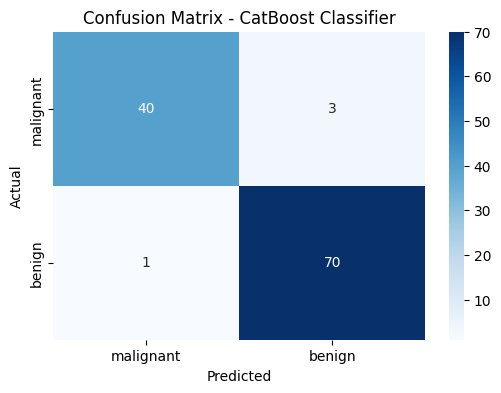

In [8]:
# 9. Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
print("CatBoost Classifier Accuracy:", accuracy)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()


## 10. You're working for a FinTech company trying to predict loan default using  customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features. Describe your step-by-step data science pipeline using boosting techniques:
 - Data preprocessing & handling missing/categorical values
 - Choice between AdaBoost, XGBoost, or CatBoost
 - Hyperparameter tuning strategy
 - Evaluation metrics you'd choose and why
 - How the business would benefit from your model


Here’s the pipeline I’d use end-to-end.

**1) Split and guardrails**

* Time-based train/val/test split (avoid leakage), stratify by default flag.
* Set a cost matrix early (FN ≫ FP). All tuning will optimize for it.

**2) Preprocess**

* Numeric: keep NaNs (tree boosters handle them), optionally median-impute if a lib demands it; winsorize extreme outliers. No scaling needed.
* Categorical:

  * CatBoost: pass column indices directly.
  * XGBoost: one-hot low-cardinality; K-fold target/impact encoding with noise for high-cardinality.
* Imbalance: class weights (`class_weights` in CatBoost, `scale_pos_weight` in XGBoost), plus **threshold tuning**; avoid SMOTE for tree boosting unless features are very sparse.

**3) Model choice**

* Start with **CatBoost**: native categorical + missing handling, strong out-of-the-box on tabular.
* Benchmark **XGBoost** as a close second (great control and speed).
* **AdaBoost** is usually weaker here; use only as a sanity baseline.

**4) Hyperparameter tuning**

* Stratified, time-aware CV (e.g., rolling windows). Early stopping on validation PR-AUC.
* Begin with randomized search → Bayesian/Optuna once ranges are scoped.
* CatBoost: tune `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `class_weights`; consider `loss_function='Logloss'`, `eval_metric='AUC:pr'`.
* XGBoost: tune `n_estimators` (with early stopping), `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_lambda/alpha`, `scale_pos_weight`.
* Lock a business threshold using validation curves (maximize expected value under cost matrix).

**5) Evaluation**

* Primary: **PR-AUC** (class imbalance) and **Recall\@target-precision** or **Precision\@K** (top-N reviews).
* Secondary: ROC-AUC, F1, Balanced Accuracy, KS.
* Calibration: Brier score + calibration plot (for risk-based pricing).
* Stability: monthly backtest, PSI/CSI.
* Explainability: SHAP for global and case-level reasons.

**6) Business impact**

* Fewer missed defaulters → lower charge-offs.
* Risk-based pricing/limits → higher approval rates at the same risk.
* Triage high-risk cases to manual review → better ops efficiency.
* Calibrated probabilities feed capital planning and compliance reporting.